# Unsupervised Learning

Notebook ini merangkum Chapter 7 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas unsupervised learning sebagai pendekatan statistik untuk menemukan struktur, pola, atau kelompok data tanpa menggunakan outcome label.

Pembahasan dibuat ringkas mengikuti format Chapter 5 yang dijadikan patokan: terdapat tujuan pembelajaran, ringkasan chapter, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, hubungan antar konsep, dan kesimpulan chapter.

## Tujuan Pembelajaran

- Memahami unsupervised learning sebagai metode untuk menganalisis data tanpa response variable.
- Menjelaskan Principal Components Analysis (PCA) untuk dimension reduction pada data numeric.
- Memahami principal components, loadings, screeplot, dan explained variance.
- Menjelaskan correspondence analysis sebagai teknik terkait untuk categorical data.
- Memahami K-Means clustering, cluster mean, within-cluster sum of squares, dan pemilihan jumlah cluster.
- Menjelaskan hierarchical clustering, dendrogram, agglomerative algorithm, dan linkage methods.
- Memahami model-based clustering melalui Gaussian mixture model.
- Menjelaskan pemilihan jumlah cluster pada model-based clustering menggunakan BIC.
- Memahami pentingnya scaling dan tantangan categorical variables dalam clustering.

## Ringkasan Chapter

Chapter ini membahas unsupervised learning, yaitu kelompok metode statistik yang digunakan ketika data tidak memiliki outcome label. Berbeda dari supervised learning yang memisahkan response variable dan predictor variables, unsupervised learning berusaha menemukan struktur internal pada data.

Bagian awal chapter membahas PCA. PCA digunakan untuk mengurangi dimensi data numeric dengan membentuk principal components, yaitu kombinasi linear dari variabel asli. Komponen pertama menjelaskan variasi terbesar, sedangkan komponen berikutnya menjelaskan variasi tersisa dengan constraint tidak berkorelasi dengan komponen sebelumnya.

Chapter kemudian membahas correspondence analysis sebagai teknik yang mirip secara tujuan visualisasi, tetapi digunakan untuk categorical data. Teknik ini terutama digunakan untuk melihat asosiasi antar kategori dalam bentuk biplot, bukan untuk dimension reduction skala besar seperti PCA.

Bagian berikutnya membahas K-Means clustering. K-Means membagi data ke dalam $K$ cluster dengan meminimalkan within-cluster sum of squares. Metode ini sederhana, cepat, dan umum digunakan pada data besar, tetapi jumlah cluster harus ditentukan pengguna dan hasilnya dapat dipengaruhi oleh scaling serta inisialisasi awal.

Hierarchical clustering dibahas sebagai alternatif K-Means. Metode ini membangun struktur cluster secara bertahap dan menampilkannya melalui dendrogram. Keunggulannya adalah interpretasi visual, tetapi skalabilitasnya lebih terbatas dibanding K-Means.

Bagian akhir chapter membahas model-based clustering, khususnya Gaussian mixture model. Pendekatan ini mengasumsikan data berasal dari campuran beberapa multivariate normal distributions. Chapter juga menekankan pentingnya scaling dan tantangan ketika clustering dilakukan pada data campuran numeric dan categorical.

## Unsupervised Learning

Unsupervised learning digunakan untuk menemukan pola tanpa label target. Tujuannya dapat berupa:

| Tujuan | Penjelasan |
|---|---|
| Clustering | Mengelompokkan records yang mirip satu sama lain. |
| Dimension reduction | Mengurangi jumlah variabel dengan tetap mempertahankan informasi utama. |
| Exploratory analysis | Memahami hubungan antar variabel dan struktur data dalam skala besar. |
| Feature engineering | Membuat feature baru untuk model supervised learning. |

Unsupervised learning juga dapat membantu pada situasi cold-start, yaitu ketika data label belum tersedia tetapi segmentasi awal tetap dibutuhkan.

## Principal Components Analysis

Principal Components Analysis atau PCA adalah teknik untuk menemukan cara variabel numeric saling bergerak bersama. PCA membentuk variabel baru yang disebut principal components. Setiap component adalah kombinasi linear dari variabel asli.

PCA berguna untuk:

- mengurangi dimensi data,
- mengurangi redundancy antar variabel,
- menemukan struktur utama dalam data numeric,
- membuat input yang lebih ringkas untuk model supervised learning.

PCA hanya digunakan untuk numeric variables. Untuk categorical data, chapter membahas correspondence analysis sebagai teknik terkait.

### Rumus Principal Component

Untuk dua variabel, principal component dapat ditulis sebagai:

$$
Z_i = w_{i,1}X_1 + w_{i,2}X_2
$$

Secara umum:

$$
Z_i = w_{i,1}X_1 + w_{i,2}X_2 + \cdots + w_{i,p}X_p
$$

Keterangan:

- $Z_i$ = principal component ke-$i$
- $X_1, X_2, \ldots, X_p$ = variabel asli
- $w_{i,j}$ = loading atau weight dari variabel ke-$j$ pada component ke-$i$

Komponen pertama menjelaskan variasi terbesar. Komponen berikutnya dibuat tidak berkorelasi dengan komponen sebelumnya dan menjelaskan variasi tersisa.

In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import pdist, squareform

np.random.seed(2024)

# Simulasi data return dua saham energi yang saling berkorelasi
n = 900
market = np.random.normal(0, 1, n)
cvx = 0.75 * market + np.random.normal(0, 0.45, n)
xom = 0.70 * market + np.random.normal(0, 0.45, n)

oil_px = pd.DataFrame({
    "CVX": cvx,
    "XOM": xom
})

pca_oil = PCA(n_components=2)
pca_oil.fit(oil_px)

loadings = pd.DataFrame(
    pca_oil.components_,
    columns=oil_px.columns,
    index=["PC1", "PC2"]
)

print("Loadings:")
display(loadings)

print("Explained variance ratio:")
print(np.round(pca_oil.explained_variance_ratio_, 3))

Loadings:


,CVX,XOM
PC1,0.713505,0.700650
PC2,-0.700650,0.713505


Explained variance ratio:
[0.862 0.138]


## Interpretasi Principal Components

Loadings menunjukkan kontribusi variabel asli terhadap setiap component. Pada contoh dua saham energi, component pertama biasanya merepresentasikan pergerakan umum kedua saham. Component kedua menangkap kondisi ketika kedua saham bergerak berbeda arah.

Tanda loading dapat berbalik tanpa mengubah makna component. Jika semua loading dikalikan $-1$, garis arah component tetap sama.

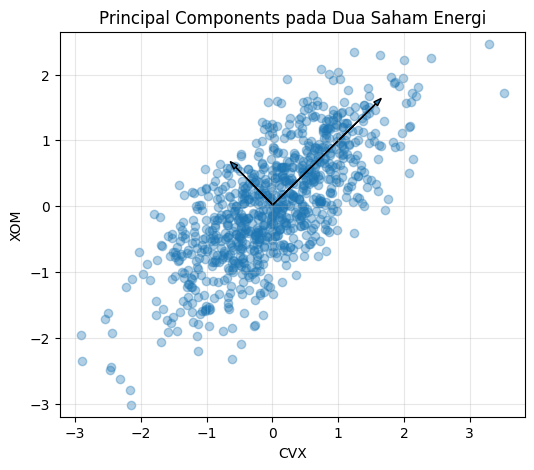

In [16]:
scores = pca_oil.transform(oil_px)

plt.figure(figsize=(6, 5))
plt.scatter(oil_px["CVX"], oil_px["XOM"], alpha=0.35)

center = oil_px.mean().values
for i in range(2):
    direction = pca_oil.components_[i] * np.sqrt(pca_oil.explained_variance_[i]) * 2
    plt.arrow(
        center[0], center[1],
        direction[0], direction[1],
        head_width=0.08,
        length_includes_head=True
    )

plt.xlabel("CVX")
plt.ylabel("XOM")
plt.title("Principal Components pada Dua Saham Energi")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.show()

## Computing Principal Components

PCA pada banyak variabel mengikuti proses yang sama. PCA mencari kombinasi linear yang menjelaskan variasi terbesar, lalu mengulangi proses untuk komponen berikutnya dengan constraint bahwa komponen-komponen tersebut tidak berkorelasi.

Langkah umum PCA:

1. Gunakan data numeric.
2. Mean-center atau standardize data jika skala variabel berbeda.
3. Hitung principal components.
4. Urutkan components berdasarkan explained variance.
5. Pilih jumlah components yang menjelaskan sebagian besar variasi data.
6. Transform data asli menjadi principal component scores.

In [17]:
# Simulasi return beberapa saham dari sektor berbeda
symbols = ["AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB", "COP",
           "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST"]

n_days = 750
market_factor = np.random.normal(0, 1, n_days)
tech_factor = np.random.normal(0, 0.7, n_days)
energy_factor = np.random.normal(0, 0.9, n_days)
finance_factor = np.random.normal(0, 0.6, n_days)
retail_factor = np.random.normal(0, 0.6, n_days)

data = {}
for sym in symbols:
    noise = np.random.normal(0, 0.5, n_days)
    value = 0.55 * market_factor + noise
    if sym in ["AAPL", "MSFT", "CSCO", "INTC"]:
        value += 0.70 * tech_factor
    elif sym in ["CVX", "XOM", "SLB", "COP"]:
        value += 0.85 * energy_factor
    elif sym in ["JPM", "WFC", "USB", "AXP"]:
        value += 0.75 * finance_factor
    else:
        value += 0.65 * retail_factor
    data[sym] = value

top_sp = pd.DataFrame(data)

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.Series(sp_pca.explained_variance_, name="explained_variance")
explained_ratio = pd.Series(sp_pca.explained_variance_ratio_, name="explained_ratio")

pd.DataFrame({
    "explained_variance": explained_variance.head(10),
    "explained_ratio": explained_ratio.head(10),
    "cumulative_ratio": explained_ratio.cumsum().head(10)
})

,explained_variance,explained_ratio,cumulative_ratio
0,6.091197,0.461096,0.461096
1,1.995071,0.151024,0.612120
2,1.203577,0.091109,0.703229
3,0.938327,0.071030,0.774259
4,0.298016,0.022559,0.796818
5,0.285320,0.021598,0.818417
6,0.284898,0.021566,0.839983
7,0.269531,0.020403,0.860386
8,0.264901,0.020053,0.880439
9,0.260296,0.019704,0.900143


## Screeplot dan Loadings

Screeplot digunakan untuk melihat seberapa besar variasi yang dijelaskan oleh setiap principal component. Jika tujuan utama adalah dimension reduction, jumlah component dapat dipilih berdasarkan:

- titik elbow pada screeplot,
- cumulative explained variance, misalnya 80%,
- interpretasi loadings pada component utama,
- atau cross-validation jika digunakan sebagai input model supervised learning.

Loadings plot membantu memahami struktur component. Misalnya, component tertentu dapat menangkap sektor energi, sektor teknologi, atau pergerakan pasar umum.

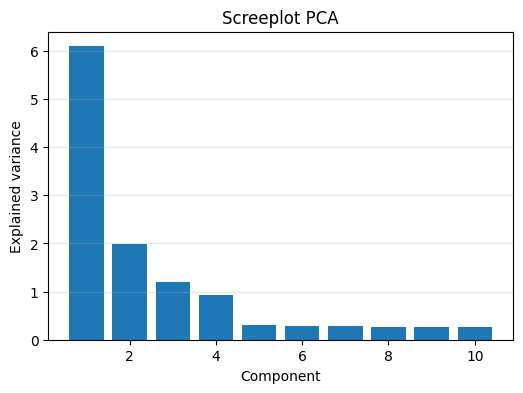

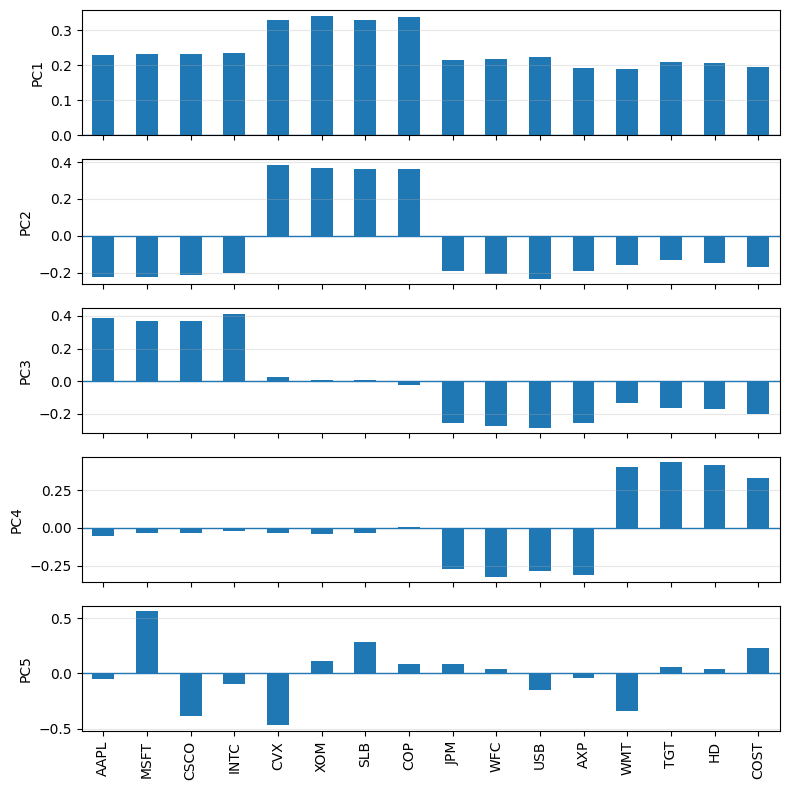

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(range(1, 11), sp_pca.explained_variance_[:10])
plt.xlabel("Component")
plt.ylabel("Explained variance")
plt.title("Screeplot PCA")
plt.grid(axis="y", alpha=0.3)
plt.show()

loadings = pd.DataFrame(sp_pca.components_[:5, :], columns=top_sp.columns)

fig, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
for i, ax in enumerate(axes):
    loadings.iloc[i].plot(kind="bar", ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_ylabel(f"PC{i+1}")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Correspondence Analysis

PCA tidak digunakan untuk categorical data. Chapter memperkenalkan correspondence analysis sebagai teknik yang secara ide mirip untuk melihat hubungan antar kategori. Inputnya berupa tabel count, dengan rows dan columns merepresentasikan dua categorical variables.

Output correspondence analysis biasanya berupa biplot yang menunjukkan kategori yang berasosiasi melalui kedekatan posisi pada plot. Namun, chapter menekankan bahwa correspondence analysis lebih umum digunakan untuk graphical analysis pada data categorical berdimensi rendah, bukan sebagai dimension reduction utama untuk big data.

,Wife,Husband,Jointly
Laundry,32,4,10
Dinner,22,18,25
Repairs,18,25,20
Driving,5,35,8
Holidays,6,12,30


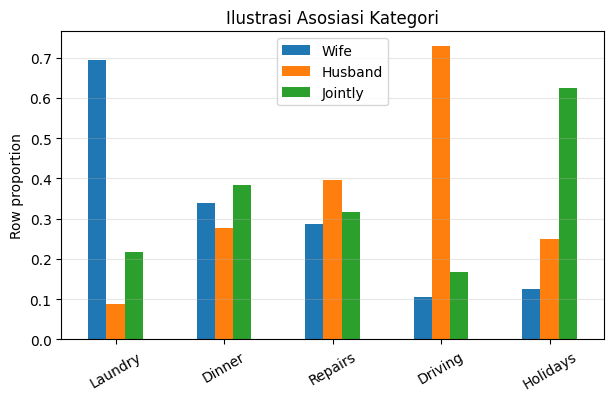

In [19]:
# Contoh tabel count sederhana untuk categorical association
tasks = pd.DataFrame(
    {
        "Wife": [32, 22, 18, 5, 6],
        "Husband": [4, 18, 25, 35, 12],
        "Jointly": [10, 25, 20, 8, 30]
    },
    index=["Laundry", "Dinner", "Repairs", "Driving", "Holidays"]
)

display(tasks)

# Visualisasi sederhana proporsi kategori
row_profiles = tasks.div(tasks.sum(axis=1), axis=0)

plt.figure(figsize=(7, 4))
row_profiles.plot(kind="bar", ax=plt.gca())
plt.ylabel("Row proportion")
plt.title("Ilustrasi Asosiasi Kategori")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

## K-Means Clustering

K-Means clustering membagi data ke dalam $K$ cluster. Records dalam cluster yang sama diharapkan mirip satu sama lain. K-Means bekerja dengan meminimalkan within-cluster sum of squares, yaitu jumlah jarak kuadrat records terhadap cluster mean masing-masing.

Istilah penting:

| Istilah | Penjelasan |
|---|---|
| Cluster | Kelompok records yang mirip. |
| Cluster mean | Vector rata-rata variabel untuk records dalam cluster. |
| $K$ | Jumlah cluster yang ditentukan pengguna. |
| Within-cluster SS | Jumlah kuadrat jarak records terhadap cluster mean. |

K-Means tidak menjamin cluster berukuran sama. Metode ini mencari cluster yang relatif terpisah berdasarkan jarak.

### Rumus Cluster Mean dan Within-Cluster SS

Untuk cluster ke-$k$ dengan $n_k$ records:

$$
\bar{x}_k =
\frac{1}{n_k}
\sum_{i \in Cluster\ k} x_i
$$

$$
\bar{y}_k =
\frac{1}{n_k}
\sum_{i \in Cluster\ k} y_i
$$

Within-cluster sum of squares:

$$
SS_k =
\sum_{i \in Cluster\ k}
\left[
(x_i-\bar{x}_k)^2 + (y_i-\bar{y}_k)^2
\right]
$$

Tujuan K-Means:

$$
\min
\sum_{k=1}^{K} SS_k
$$

Keterangan:

- $\bar{x}_k, \bar{y}_k$ = cluster mean untuk cluster ke-$k$
- $SS_k$ = within-cluster sum of squares untuk cluster ke-$k$
- $K$ = jumlah cluster

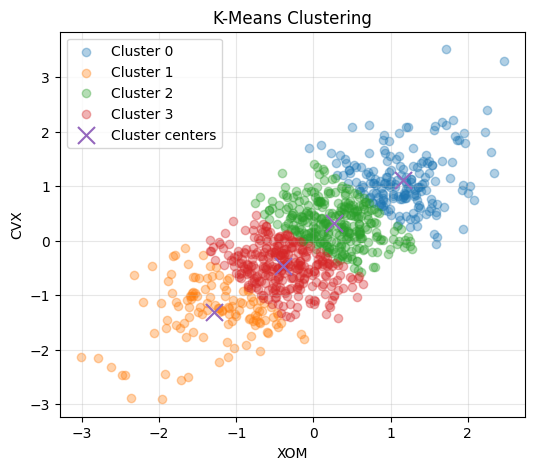

Cluster sizes:


cluster
0    183
1    122
2    300
3    295
Name: count, dtype: int64

Cluster centers:


,XOM,CVX
0,1.161570,1.122201
1,-1.291029,-1.302164
2,0.264176,0.325704
3,-0.398904,-0.471546


In [20]:
# Simulasi dua return saham seperti contoh XOM-CVX
stock_df = oil_px.copy()

kmeans = KMeans(n_clusters=4, random_state=2024, n_init=10)
stock_df["cluster"] = kmeans.fit_predict(stock_df[["XOM", "CVX"]])

centers = pd.DataFrame(kmeans.cluster_centers_, columns=["XOM", "CVX"])

plt.figure(figsize=(6, 5))
for cluster_id, group in stock_df.groupby("cluster"):
    plt.scatter(group["XOM"], group["CVX"], alpha=0.35, label=f"Cluster {cluster_id}")

plt.scatter(centers["XOM"], centers["CVX"], marker="x", s=150, label="Cluster centers")
plt.xlabel("XOM")
plt.ylabel("CVX")
plt.title("K-Means Clustering")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Cluster sizes:")
display(stock_df["cluster"].value_counts().sort_index())

print("Cluster centers:")
display(centers)

## K-Means Algorithm

K-Means menggunakan algoritma iteratif. Solusi exact untuk K-Means sulit dihitung pada data besar, sehingga digunakan heuristic yang mencari solusi lokal terbaik.

Langkah algoritma:

1. Tentukan jumlah cluster $K$.
2. Tentukan initial cluster means.
3. Assign setiap record ke cluster mean terdekat.
4. Hitung ulang cluster means berdasarkan assignment baru.
5. Ulangi langkah 3 dan 4 sampai assignment tidak berubah.

Karena hasil dapat dipengaruhi initial cluster means, algoritma sebaiknya dijalankan beberapa kali dengan random starts berbeda. Pada scikit-learn, parameter `n_init` digunakan untuk mengatur jumlah inisialisasi.

## Interpreting the Clusters

Interpretasi cluster biasanya dilakukan dengan melihat:

- ukuran setiap cluster,
- cluster means,
- apakah cluster seimbang atau sangat timpang,
- apakah cluster merepresentasikan pola yang masuk akal.

Cluster yang sangat kecil dapat menunjukkan outlier atau kelompok records yang benar-benar berbeda dari data lain. Dalam contoh return saham, cluster dapat merepresentasikan hari pasar naik, pasar turun, atau kondisi sektor tertentu bergerak berlawanan.

Cluster sizes:


0    107
1    173
2    134
3    224
4    112
Name: count, dtype: int64

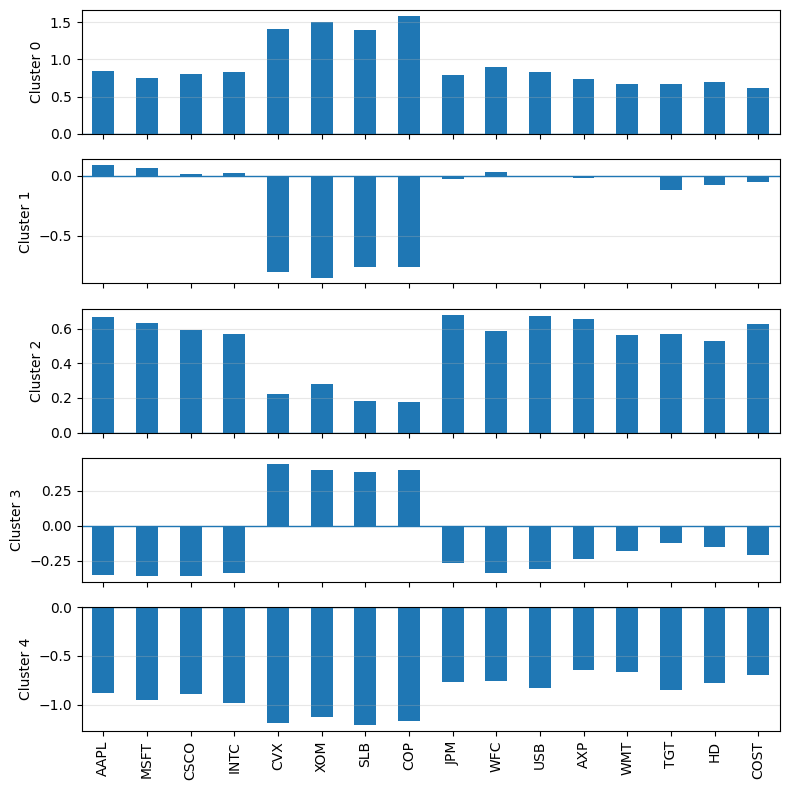

In [21]:
kmeans_sp = KMeans(n_clusters=5, random_state=2024, n_init=10)
cluster_labels = kmeans_sp.fit_predict(top_sp)

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
cluster_centers = pd.DataFrame(kmeans_sp.cluster_centers_, columns=top_sp.columns)

print("Cluster sizes:")
display(cluster_sizes)

fig, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
for i, ax in enumerate(axes):
    cluster_centers.iloc[i].plot(kind="bar", ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_ylabel(f"Cluster {i}")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Selecting the Number of Clusters

K-Means mengharuskan pengguna menentukan jumlah cluster $K$. Dalam banyak kasus, jumlah cluster ditentukan oleh kebutuhan aplikasi, misalnya jumlah customer personas yang dapat ditindaklanjuti oleh tim bisnis.

Jika tidak ada alasan praktis, pendekatan statistik yang sering digunakan adalah elbow method. Ide dasarnya adalah melihat penurunan within-cluster squared distances ketika $K$ bertambah. Titik elbow adalah titik ketika penambahan cluster berikutnya tidak lagi memberi penurunan besar.

Namun, chapter menekankan bahwa tidak ada aturan tunggal yang selalu dapat menentukan jumlah cluster terbaik.

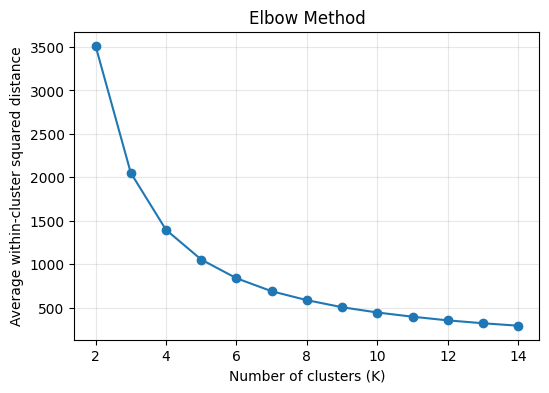

In [22]:
inertia_values = []

for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=2024, n_init=10)
    km.fit(top_sp)
    inertia_values.append(km.inertia_ / k)

plt.figure(figsize=(6, 4))
plt.plot(range(2, 15), inertia_values, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Average within-cluster squared distance")
plt.title("Elbow Method")
plt.grid(alpha=0.3)
plt.show()

## Hierarchical Clustering

Hierarchical clustering adalah alternatif dari K-Means. Metode ini membangun hierarchy cluster dan biasanya divisualisasikan melalui dendrogram. Pengguna tidak harus menentukan jumlah cluster sejak awal; jumlah cluster dapat dipilih setelah melihat dendrogram.

Hierarchical clustering lebih mudah diinterpretasikan secara visual dan dapat membantu menemukan outlier atau kelompok kecil yang berbeda. Namun, metode ini tidak scalable untuk data yang sangat besar.

## Dendrogram dan Agglomerative Algorithm

Hierarchical clustering yang dibahas chapter menggunakan agglomerative algorithm. Algoritma ini dimulai dari setiap record sebagai cluster sendiri, lalu secara bertahap menggabungkan cluster yang paling mirip.

Langkah agglomerative algorithm:

1. Setiap record menjadi cluster tunggal.
2. Hitung dissimilarity antar semua pasangan cluster.
3. Gabungkan dua cluster yang paling tidak berbeda.
4. Ulangi sampai seluruh records menjadi satu cluster.

Dendrogram menyimpan sejarah penggabungan cluster. Panjang cabang menunjukkan tingkat dissimilarity.

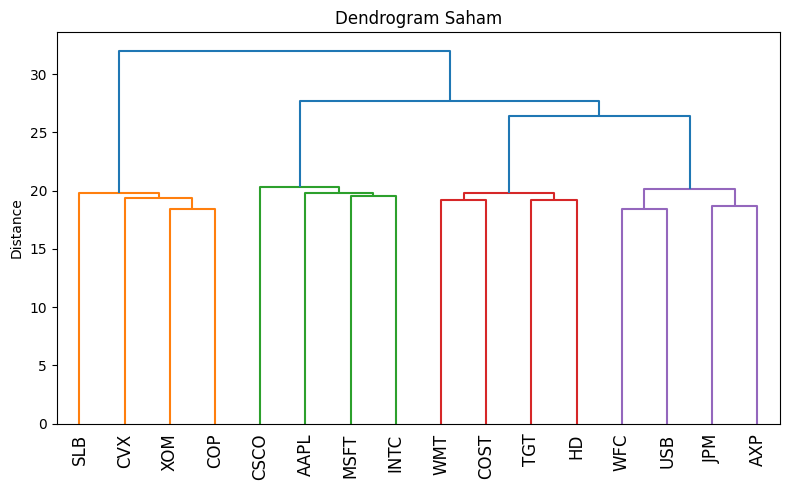

Cluster membership:


COP     1
SLB     1
XOM     1
CVX     1
INTC    2
CSCO    2
MSFT    2
AAPL    2
COST    3
HD      3
TGT     3
WMT     3
AXP     4
USB     4
WFC     4
JPM     4
Name: cluster, dtype: int32

In [23]:
# Contoh hierarchical clustering pada "perusahaan" berdasarkan return
company_df = top_sp.T

Z = linkage(company_df, method="complete")

plt.figure(figsize=(8, 5))
dendrogram(Z, labels=company_df.index, leaf_rotation=90)
plt.ylabel("Distance")
plt.title("Dendrogram Saham")
plt.tight_layout()
plt.show()

memb = fcluster(Z, 4, criterion="maxclust")
membership = pd.Series(memb, index=company_df.index, name="cluster")

print("Cluster membership:")
display(membership.sort_values())

## Measures of Dissimilarity

Hierarchical clustering membutuhkan ukuran dissimilarity antar cluster. Chapter membahas empat pendekatan umum:

| Linkage Method | Penjelasan |
|---|---|
| Complete linkage | Jarak maksimum antar records dari dua cluster. |
| Single linkage | Jarak minimum antar records dari dua cluster. |
| Average linkage | Rata-rata jarak semua pasangan records antar cluster. |
| Ward / minimum variance | Menggabungkan cluster yang menjaga within-cluster sum of squares tetap kecil. |

Complete linkage cenderung menghasilkan cluster dengan anggota yang lebih mirip. Single linkage dapat menjadi terlalu greedy dan membuat sebagian besar data masuk satu cluster. Ward method sering menghasilkan pola yang mirip K-Means.

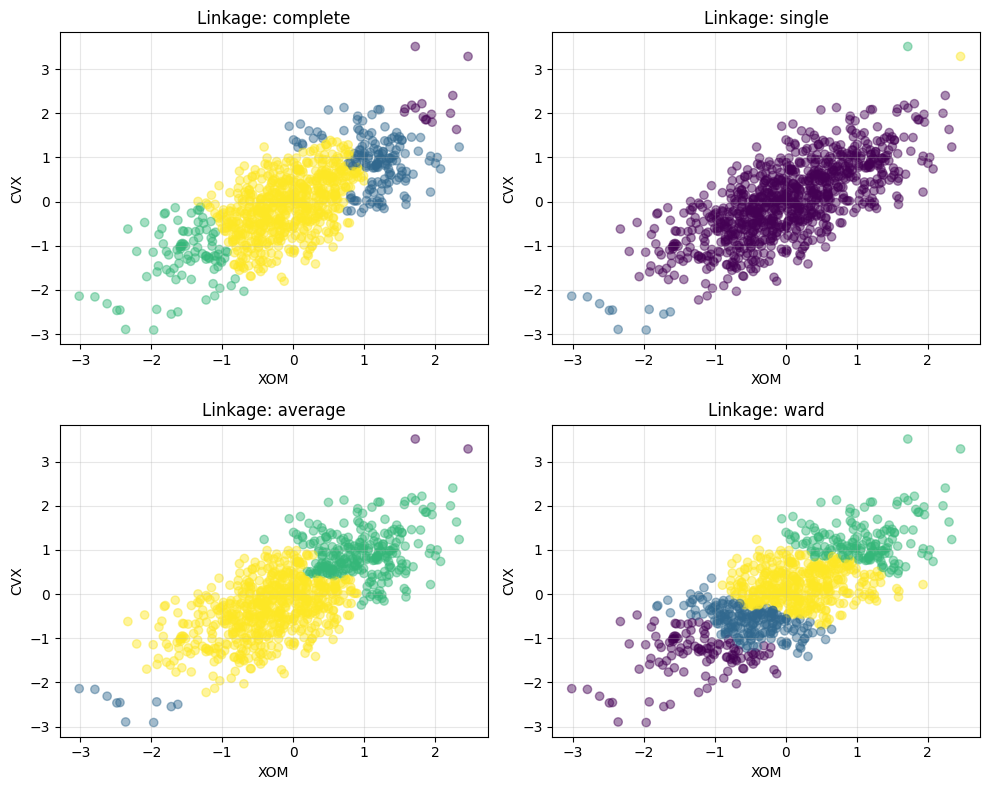

In [24]:
methods = ["complete", "single", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, method in zip(axes, methods):
    Z_method = linkage(oil_px[["XOM", "CVX"]], method=method)
    clusters = fcluster(Z_method, 4, criterion="maxclust")

    ax.scatter(oil_px["XOM"], oil_px["CVX"], c=clusters, alpha=0.45)
    ax.set_title(f"Linkage: {method}")
    ax.set_xlabel("XOM")
    ax.set_ylabel("CVX")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model-Based Clustering

Model-based clustering menggunakan pendekatan statistik. Data diasumsikan berasal dari campuran beberapa distribusi, biasanya multivariate normal distributions. Setiap cluster direpresentasikan oleh distribusi dengan mean dan covariance matrix sendiri.

Untuk dua variabel $X$ dan $Y$, data dapat dimodelkan sebagai berasal dari salah satu dari $K$ distribusi:

$$
N(\mu_1,\Sigma_1),
N(\mu_2,\Sigma_2),
\ldots,
N(\mu_K,\Sigma_K)
$$

Keterangan:

- $\mu_k$ = mean vector cluster ke-$k$
- $\Sigma_k$ = covariance matrix cluster ke-$k$
- $K$ = jumlah komponen atau cluster

Pendekatan ini disebut juga Gaussian mixture model.

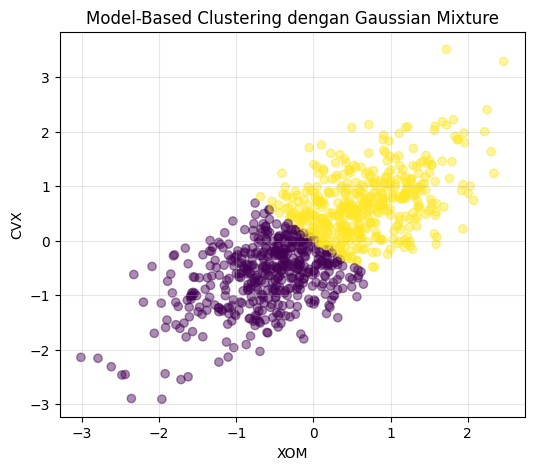

Means:


,XOM,CVX
0,-0.465768,-0.491780
1,0.514184,0.514876


Covariance matrices shape: (2, 2, 2)
First five membership probabilities:


,Component 0,Component 1
0,0.070199,0.929801
1,0.160597,0.839403
2,0.623636,0.376364
3,0.708057,0.291943
4,0.065542,0.934458


In [25]:
gmm = GaussianMixture(n_components=2, random_state=2024)
gmm.fit(oil_px[["XOM", "CVX"]])

gmm_clusters = gmm.predict(oil_px[["XOM", "CVX"]])
gmm_probs = gmm.predict_proba(oil_px[["XOM", "CVX"]])

plt.figure(figsize=(6, 5))
plt.scatter(oil_px["XOM"], oil_px["CVX"], c=gmm_clusters, alpha=0.45)
plt.xlabel("XOM")
plt.ylabel("CVX")
plt.title("Model-Based Clustering dengan Gaussian Mixture")
plt.grid(alpha=0.3)
plt.show()

print("Means:")
display(pd.DataFrame(gmm.means_, columns=["XOM", "CVX"]))

print("Covariance matrices shape:", gmm.covariances_.shape)
print("First five membership probabilities:")
display(pd.DataFrame(gmm_probs, columns=["Component 0", "Component 1"]).head())

## Selecting the Number of Clusters in Model-Based Clustering

Pada model-based clustering, jumlah cluster dapat dipilih dengan membandingkan model menggunakan Bayesian Information Criterion atau BIC. BIC memberi penalti terhadap jumlah parameter, sehingga penambahan cluster tidak otomatis dianggap lebih baik.

Dalam scikit-learn, nilai BIC biasanya diminimalkan.

Secara konsep:

| Nilai BIC | Interpretasi |
|---|---|
| Lebih kecil | Model lebih disukai pada definisi BIC scikit-learn. |
| Lebih besar | Model kurang disukai. |

Chapter menjelaskan bahwa pemilihan jumlah cluster berbasis BIC lebih formal dibanding elbow method, tetapi hasilnya tetap perlu ditafsirkan berdasarkan konteks data.

,n_components,covariance_type,bic
0,1,full,4010.832525


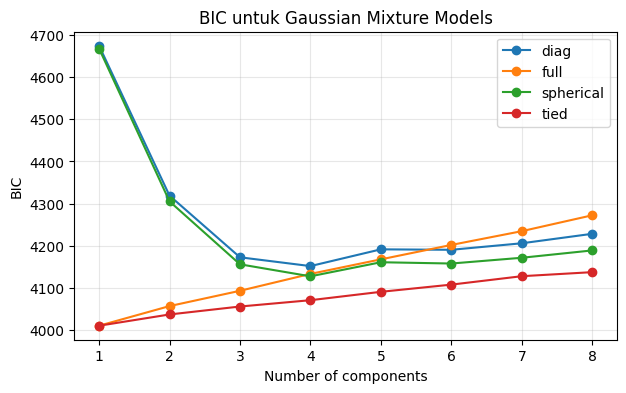

In [26]:
results = []

for n_components in range(1, 9):
    for covariance_type in ["full", "tied", "diag", "spherical"]:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=2024
        )
        model.fit(oil_px[["XOM", "CVX"]])
        results.append({
            "n_components": n_components,
            "covariance_type": covariance_type,
            "bic": model.bic(oil_px[["XOM", "CVX"]])
        })

bic_df = pd.DataFrame(results)
best_bic = bic_df.sort_values("bic").head(1)

display(best_bic)

plt.figure(figsize=(7, 4))
for covariance_type, group in bic_df.groupby("covariance_type"):
    plt.plot(group["n_components"], group["bic"], marker="o", label=covariance_type)

plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC untuk Gaussian Mixture Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Scaling and Categorical Variables

Scaling sangat penting dalam PCA dan clustering. Jika variabel memiliki skala berbeda, variabel berskala besar dapat mendominasi distance, covariance, atau clustering result.

Standardization umum digunakan:

$$
z =
\frac{x-\bar{x}}{s}
$$

Namun, scaling tidak selalu menyelesaikan semua masalah. Untuk data campuran numeric dan categorical, categorical variables yang diubah menjadi dummy variables dapat mendominasi cluster karena setiap category menjadi binary feature tersendiri.

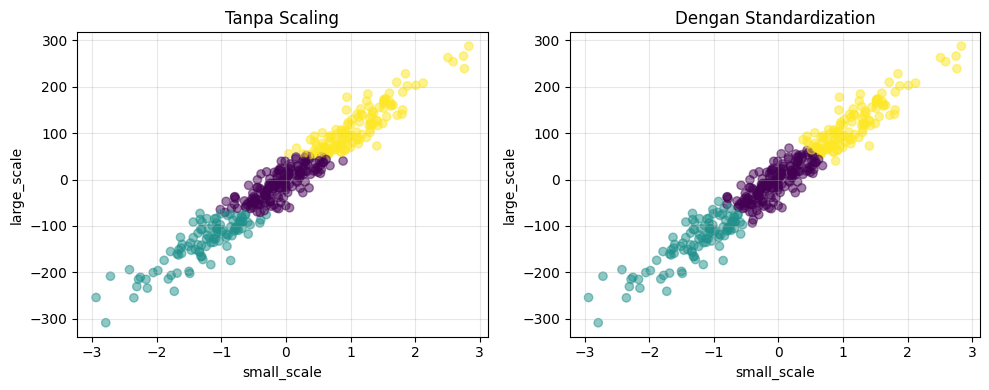

In [27]:
# Contoh pengaruh scaling pada clustering
n = 400
small_scale = np.random.normal(0, 1, n)
large_scale = 100 * small_scale + np.random.normal(0, 25, n)

scale_df = pd.DataFrame({
    "small_scale": small_scale,
    "large_scale": large_scale
})

km_raw = KMeans(n_clusters=3, random_state=2024, n_init=10)
scale_df["cluster_raw"] = km_raw.fit_predict(scale_df[["small_scale", "large_scale"]])

scaler = StandardScaler()
scaled_values = scaler.fit_transform(scale_df[["small_scale", "large_scale"]])

km_scaled = KMeans(n_clusters=3, random_state=2024, n_init=10)
scale_df["cluster_scaled"] = km_scaled.fit_predict(scaled_values)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(scale_df["small_scale"], scale_df["large_scale"], c=scale_df["cluster_raw"], alpha=0.5)
axes[0].set_title("Tanpa Scaling")
axes[0].set_xlabel("small_scale")
axes[0].set_ylabel("large_scale")
axes[0].grid(alpha=0.3)

axes[1].scatter(scale_df["small_scale"], scale_df["large_scale"], c=scale_df["cluster_scaled"], alpha=0.5)
axes[1].set_title("Dengan Standardization")
axes[1].set_xlabel("small_scale")
axes[1].set_ylabel("large_scale")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Gower's Distance dan Mixed Data

Chapter menyebut Gower's distance sebagai salah satu pendekatan untuk data campuran numeric dan categorical. Ide umumnya adalah mengubah setiap variabel ke skala 0 sampai 1, lalu menghitung similarity atau dissimilarity secara seimbang.

Namun, clustering mixed data tetap sulit. Jika terlalu banyak dummy variables dari categorical data, clustering dapat lebih mencerminkan kategori daripada pola numeric yang ingin dicari. Salah satu strategi praktis adalah melakukan clustering secara terpisah pada subset data berdasarkan kategori penting.

In [28]:
# Ilustrasi sederhana: dummy variables dapat mendominasi cluster
mixed = pd.DataFrame({
    "dti": np.random.normal(18, 6, 500).clip(1, 40),
    "payment_inc_ratio": np.random.gamma(2, 3, 500).clip(0, 25),
    "home": np.random.choice(["MORTGAGE", "OWN", "RENT"], 500, p=[0.45, 0.10, 0.45]),
    "pub_rec_zero": np.random.choice([0, 1], 500, p=[0.15, 0.85])
})

mixed_encoded = pd.get_dummies(mixed, columns=["home"], dtype=int)

scaled_mixed = StandardScaler().fit_transform(mixed_encoded)
km_mixed = KMeans(n_clusters=4, random_state=2024, n_init=10)
mixed["cluster"] = km_mixed.fit_predict(scaled_mixed)

cluster_profile = mixed.groupby("cluster").agg({
    "dti": "mean",
    "payment_inc_ratio": "mean",
    "pub_rec_zero": "mean",
    "home": lambda x: x.value_counts().index[0]
})

cluster_profile

,dti,payment_inc_ratio,pub_rec_zero,home
cluster,,,,
0,18.214934,6.604453,0.8,OWN
1,18.084623,6.282496,1.0,MORTGAGE
2,18.287368,6.236309,1.0,RENT
3,17.133082,5.865698,0.0,MORTGAGE


## Hubungan Antar Konsep

| Konsep | Deskripsi |
|---|---|
| Unsupervised learning | Metode untuk menemukan struktur data tanpa outcome label. |
| PCA | Dimension reduction dengan membentuk kombinasi linear variabel numeric. |
| Principal component | Variabel baru hasil weighted linear combination dari variabel asli. |
| Loadings | Bobot variabel asli dalam principal component. |
| Screeplot | Visualisasi explained variance setiap component. |
| Correspondence analysis | Teknik visual untuk asosiasi antar kategori. |
| K-Means | Clustering dengan meminimalkan within-cluster sum of squares. |
| Cluster mean | Vector rata-rata variabel dalam cluster. |
| Elbow method | Pendekatan visual untuk memilih jumlah cluster. |
| Hierarchical clustering | Clustering bertahap yang divisualisasikan dengan dendrogram. |
| Dendrogram | Diagram pohon yang menunjukkan sejarah penggabungan cluster. |
| Linkage method | Cara menghitung dissimilarity antar cluster. |
| Model-based clustering | Clustering berbasis campuran distribusi probabilistik. |
| Gaussian mixture | Model cluster berbasis multivariate normal distributions. |
| BIC | Kriteria untuk memilih jumlah komponen pada model-based clustering. |
| Scaling | Transformasi skala variabel agar pengaruhnya lebih seimbang. |

## Kesimpulan Chapter

Chapter ini menjelaskan unsupervised learning sebagai pendekatan untuk menemukan struktur dalam data tanpa response variable. Metode ini dapat digunakan untuk exploratory analysis, clustering, dimension reduction, feature engineering, atau tahap awal saat label belum tersedia.

PCA digunakan untuk dimension reduction pada data numeric. Principal components adalah kombinasi linear variabel asli yang dirancang untuk menjelaskan variasi terbesar dan mengurangi redundancy antar variabel. Screeplot dan loadings membantu memilih serta menafsirkan components.

K-Means clustering membagi records ke dalam $K$ cluster dengan meminimalkan within-cluster sum of squares. Metode ini sederhana dan scalable, tetapi pengguna harus menentukan jumlah cluster dan memperhatikan scaling variabel.

Hierarchical clustering membangun cluster secara bertahap dari setiap record individual hingga menjadi satu cluster besar. Dendrogram membuat struktur cluster lebih mudah dilihat, tetapi metode ini kurang cocok untuk data sangat besar.

Model-based clustering menggunakan pendekatan probabilistik, terutama campuran multivariate normal distributions. Jumlah cluster dapat dipilih melalui BIC, tetapi hasil model tetap perlu ditafsirkan sesuai konteks data.

Secara keseluruhan, tidak ada satu metode clustering yang selalu paling baik. PCA, K-Means, hierarchical clustering, dan model-based clustering memiliki tujuan, asumsi, dan keterbatasan masing-masing. Pemilihan metode harus mempertimbangkan ukuran data, tipe variabel, kebutuhan interpretasi, dan tujuan analisis.